In [1]:
import numpy as np
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Conv2D,BatchNormalization,Dense,MaxPooling2D,Flatten,Dropout
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import os
import gradio as gr


In [2]:
encoder = OneHotEncoder(sparse_output=False)
encoder.fit([[0],[1]])

OneHotEncoder(sparse_output=False)

In [3]:
data = []
paths = []
results = []

In [4]:
yes_folder = '/Users/pashantraj/Desktop/brain_tumor_dataset/yes'
paths = []

# Gather all image paths
for r, d, f in os.walk(yes_folder):
    for file in f:
        if file.lower().endswith('.jpg'):
            paths.append(os.path.join(r, file))

# Load and preprocess images
for path in paths:
    try:
        img = Image.open(path).resize((128, 128)).convert('RGB')
        img = np.array(img)
        if img.shape == (128, 128, 3):
            data.append(img)
            results.append(encoder.transform([[0]])[0])  # 0 = yes (tumor)
    except Exception as e:
        print(f"Error loading {path}: {e}")

In [5]:
no_folder = '/Users/pashantraj/Desktop/brain_tumor_dataset/no'
paths = []

# Gather all image paths
for r, d, f in os.walk(no_folder):
    for file in f:
        if file.lower().endswith('.jpg'):
            paths.append(os.path.join(r, file))

# Load and preprocess images
for path in paths:
    try:
        img = Image.open(path).resize((128, 128)).convert('RGB')
        img = np.array(img)
        if img.shape == (128, 128, 3):
            data.append(img)
            results.append(encoder.transform([[1]])[0])  # 1 = no (tumor)
    except Exception as e:
        print(f"Error loading {path}: {e}")

In [6]:
data = np.array(data) 
data.shape

(245, 128, 128, 3)

In [7]:
results = np.array(results)
results.shape

(245, 2)

In [8]:
x_train,x_test,y_train,y_test = train_test_split(data,results,shuffle=True,random_state=0,test_size=0.2)

In [9]:
print(f"Number of Images in Training data set is {len(x_train)}")

Number of Images in Training data set is 196


In [10]:
print(f"Number of Images in Testing data set is {len(x_test)}")

Number of Images in Testing data set is 49


In [11]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(2, 2), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(2, 2),  activation ='relu', padding = 'Same'))


model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3, 3),strides=(3,3)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(3,3), strides=(3,3)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(100, activation='relu'))
model.add(Dropout(0.45))
model.add(Dense(2, activation='softmax'))

model.compile(loss = "categorical_crossentropy", optimizer='Adamax')
print(model.summary())

/opt/homebrew/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 42, 42, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 42, 42, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 42, 42, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 42, 42, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │     1,254,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           202 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,284,334 (4.90 MB)

 Trainable params: 1,284,142 (4.90 MB)

 Non-trainable params: 192 (768.00 B)

None


In [12]:
y_train.shape

(196, 2)

In [13]:
history = model.fit(x_train,y_train,epochs=30,batch_size=35,validation_data=(x_test,y_test))

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step - loss: 3.0530 - val_loss: 2.2336
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - loss: 1.9234 - val_loss: 1.2926
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 248ms/step - loss: 2.2573 - val_loss: 1.1560
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 241ms/step - loss: 0.9311 - val_loss: 3.1296
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 220ms/step - loss: 0.9619 - val_loss: 0.5635
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 1.0095 - val_loss: 0.5138
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.3719 - val_loss: 0.5721
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 222ms/step - loss: 0.4611 - val_loss: 0.3720
Epoch 9/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 215ms/step - loss: 0.2553 - val_loss: 0.4936
Epoch 10/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - loss: 0.2182 - val_loss: 0.5237
Epoch 11/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - loss: 0.2294 - val_loss: 0.3579
Epoch 12/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 216ms/step - loss: 0.2865 - val_lo

In [14]:
def decide(res):
    result = np.argmax(res[0])
    if (result == 0):
        return f'yes, with {res[0][result] * 100}% confidence'
    else:
        return f'No, with {res[0][result] * 100}% confidence'

No, with 93.93756985664368% confidence


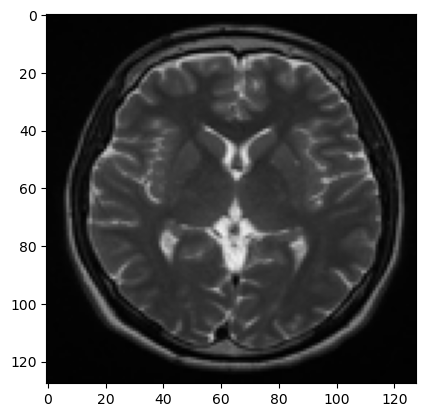

In [15]:
img_test1 = Image.open('No22.jpg').resize((128, 128)).convert('RGB')
plt.imshow(img_test1)
img_test1 = np.array(img_test1)
img_test1 = np.expand_dims(img_test1, axis=0)
#print(img_test1.shape)
res = model.predict_on_batch(img_test1)
print(decide(res))

yes, with 99.37272071838379% confidence


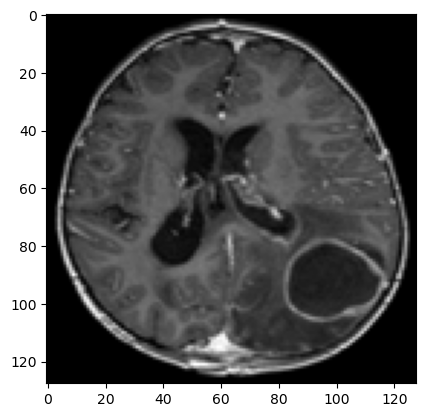

In [16]:
img_test2 = Image.open('Y257.jpg').resize((128, 128)).convert('RGB')
img_test2 = np.array(img_test2)
plt.imshow(img_test2)
img_test2 = np.expand_dims(img_test2, axis=0)
#print(img_test2.shape)
res2 = model.predict_on_batch(img_test2)

print(decide(res2))

In [17]:
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)


In [18]:
# heading_title = 'Project 1 BRAIN TUMOUR DETECTION'

In [19]:
# num_examples = 2

In [20]:
# examples = []
# examples.append('/Users/pashantraj/Desktop/brain_tumor_dataset/No22.jpg')
# examples.append('/Users/pashantraj/Desktop/brain_tumor_dataset/Y257.jpg')

In [21]:
# examples

In [22]:
# #@title You can also add some description and explanation
# #  to your app's interace if you want. Go ahead and specify some text for the description and the long description (if you want to):
# desc = "Brain tumor app. Let's learn!" # @param {type:"string"}
# long_desc = "Select an image or upload one to predict if brain tumor is present or not" # @param {type:"string"}

In [23]:

# theme_selection = 'Glass'

# theme_dict = {
#     "Base": gr.themes.Base(),
#     "Default": gr.themes.Default(),
#     "Glass": gr.themes.Glass(),
#     "Monochrome": gr.themes.Monochrome(),
#     "Soft": gr.themes.Soft()
# }

# selected_theme = theme_dict[theme_selection]

In [24]:
# def recognize_img(image):
#     img = Image.fromarray(image).resize((128,128))

#     x = np.array(img)
#     x.resize(1,128,128,3)

#     res = model.predict_on_batch(x)
#     res = np.argmax(res[0])
#     classification = ['Tumor','No, Tumor']
#     return f'{classification[res]}' 
    
    

In [25]:
# # Assuming recognize_image, examples, heading_title, desc, long_desc, and selected_theme are defined elsewhere.

# # Update the import for components
# image = gr.Image()
# label = gr.Label()

# # Create the interface with the updated component imports
# iface = gr.Interface(
#     fn=recognize_img,
#     inputs=image,
#     outputs=label,
#     examples=examples,
#     title=heading_title,
#     description=desc,
#     article=long_desc,
#     theme=selected_theme  # Make sure this is defined based on user selection as explained in previous messages
# )

# iface.launch(share=True, debug=True)